# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Load Dataset

In [2]:
df = pd.read_csv("features_3_sec.csv")
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


# Label encoding

In [3]:
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

In [4]:
# Split features and labels
X = df.drop(columns=["filename", "label", "label_encoded"])
y = df["label_encoded"]


# Feature scaling & Train-test split

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df.dropna(inplace=True)

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

X = df.drop(columns=["filename", "label", "label_encoded"])
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Tensors & Data loaders

In [12]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

# MLP model

In [13]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.model(x)

# Loss & optimizer

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(X_train.shape[1], 128, len(le.classes_)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# Training loop

In [15]:
def train_model():
    for epoch in range(20):
        model.train()
        total, correct, running_loss = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
        print(f"Epoch {epoch+1} | Loss: {running_loss/total:.4f} | Acc: {correct/total:.4f}")


# Evaluation

In [16]:
def evaluate():
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_preds

# Run
train_model()
y_true, y_pred = evaluate()

Epoch 1 | Loss: 7257.2265 | Acc: 0.3159
Epoch 2 | Loss: 2460.4155 | Acc: 0.3642
Epoch 3 | Loss: 1452.4431 | Acc: 0.3830
Epoch 4 | Loss: 950.3558 | Acc: 0.3772
Epoch 5 | Loss: 641.6544 | Acc: 0.3827
Epoch 6 | Loss: 452.7411 | Acc: 0.3750
Epoch 7 | Loss: 345.5870 | Acc: 0.3838
Epoch 8 | Loss: 254.3108 | Acc: 0.3981
Epoch 9 | Loss: 174.3820 | Acc: 0.3944
Epoch 10 | Loss: 147.4089 | Acc: 0.3856
Epoch 11 | Loss: 106.0479 | Acc: 0.4058
Epoch 12 | Loss: 88.6073 | Acc: 0.4010
Epoch 13 | Loss: 68.2785 | Acc: 0.3904
Epoch 14 | Loss: 55.0726 | Acc: 0.4084
Epoch 15 | Loss: 45.7296 | Acc: 0.3925
Epoch 16 | Loss: 36.4325 | Acc: 0.3968
Epoch 17 | Loss: 30.7122 | Acc: 0.3952
Epoch 18 | Loss: 22.1864 | Acc: 0.4015
Epoch 19 | Loss: 14.8542 | Acc: 0.3899
Epoch 20 | Loss: 7.4559 | Acc: 0.3753


# Results & Classification Report

In [20]:
acc = accuracy_score(y_true, y_pred)
print("\nTest Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=le.classes_))



Test Accuracy: 0.3591101694915254

Classification Report:
               precision    recall  f1-score   support

       blues       0.22      0.61      0.33       200
   classical       0.81      0.73      0.77       200
     country       0.34      0.21      0.26       199
       disco       0.33      0.04      0.06       200
      hiphop       0.32      0.15      0.21       145

    accuracy                           0.36       944
   macro avg       0.40      0.35      0.32       944
weighted avg       0.41      0.36      0.33       944



# Confusion matrix

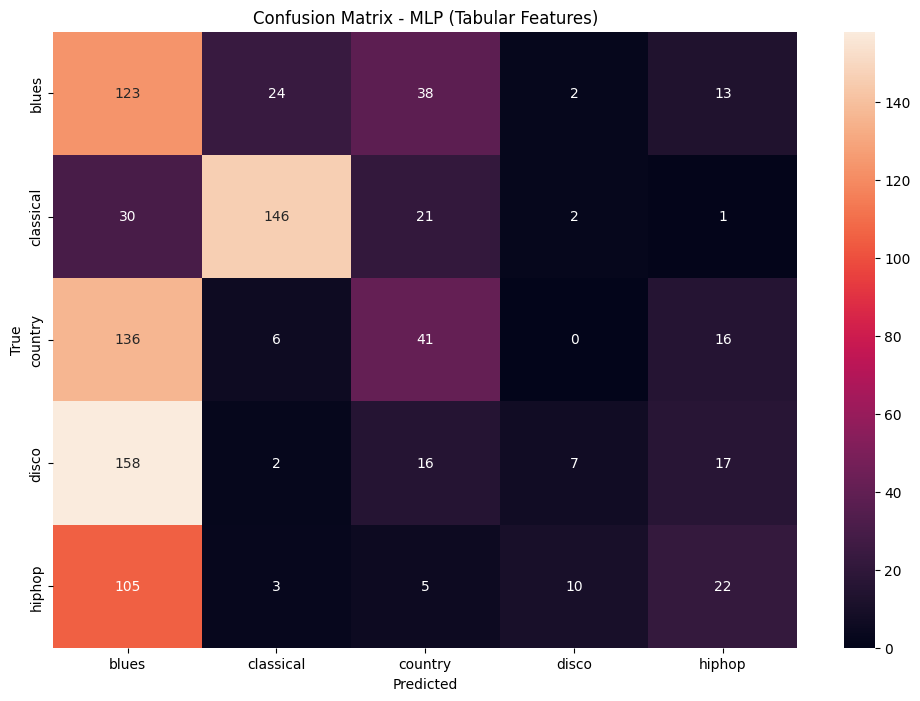

In [21]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - MLP (Tabular Features)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
